<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-01-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 03
### Installation, Python Programming and Statistical Concepts

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | 125M1H044|
| **Student Name** | Ishita Khandelwal|
| **Submission Date** | 31/08/2026|
</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Question 1 - Data Preprocessing and exploration



a: normalize and remove ouliers using Min-Max scaling


In [25]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("product_prices - product_prices.csv")

df.head()

,ProductID,ProductName,Category,Brand,UnitPrice,Discount,Stock
0,P001,Smartphone X100,Electronics,BrandA,25000,10,50
1,P002,Laptop Pro 14,Electronics,BrandB,750000,15,30
2,P003,Wireless Mouse,Accessories,BrandC,800,5,120
3,P004,"LED Monitor 24""",Electronics,BrandA,12000,10,40
4,P005,Office Chair,Furniture,BrandD,5000,8,60


In [26]:
df.describe()

,UnitPrice,Discount,Stock
count,20.000000,20.000000,20.000000
mean,97684.950000,12.800000,51.500000
std,269144.830985,6.955498,28.958228
min,800.000000,5.000000,12.000000
25%,3175.000000,8.000000,29.500000
50%,7750.000000,10.000000,47.500000
75%,25750.000000,15.750000,62.500000
max,999999.000000,30.000000,120.000000


In [27]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)

IQR= Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(upper_bound,lower_bound)

df_clean = df[
    (df['UnitPrice'] >= lower_bound) & (df['UnitPrice'] <= upper_bound)
].copy()

print("cleaned data")
print(df_clean)

59612.5 -30687.5
cleaned data
   ProductID        ProductName         Category   Brand  UnitPrice  Discount  \
0       P001    Smartphone X100      Electronics  BrandA      25000        10   
2       P003     Wireless Mouse      Accessories  BrandC        800         5   
3       P004    LED Monitor 24"      Electronics  BrandA      12000        10   
4       P005       Office Chair        Furniture  BrandD       5000         8   
5       P006          Bookshelf        Furniture  BrandD       3500         5   
6       P007    Air Conditioner  Home Appliances  BrandE      30000        20   
7       P008  Refrigerator 260L  Home Appliances  BrandE      28000        18   
8       P009        Blender Pro          Kitchen  BrandF       2200        12   
9       P010     Microwave Oven          Kitchen  BrandF       9500        10   
10      P011       Smartwatch Z      Electronics  BrandG       7000        25   
11      P012  Bluetooth Speaker      Accessories  BrandC       1800        15  

In [28]:
scaler = MinMaxScaler()

df_clean['Normalized_Price'] = scaler.fit_transform(df_clean[['UnitPrice']])

print("final dataset")
print(df_clean[['ProductName', 'UnitPrice','Normalized_Price']])

final dataset
          ProductName  UnitPrice  Normalized_Price
0     Smartphone X100      25000          0.617347
2      Wireless Mouse        800          0.000000
3     LED Monitor 24"      12000          0.285714
4        Office Chair       5000          0.107143
5           Bookshelf       3500          0.068878
6     Air Conditioner      30000          0.744898
7   Refrigerator 260L      28000          0.693878
8         Blender Pro       2200          0.035714
9      Microwave Oven       9500          0.221939
10       Smartwatch Z       7000          0.158163
11  Bluetooth Speaker       1800          0.025510
12       Tablet 10.1"      18000          0.438776
14     Gaming Console      40000          1.000000
15        Ceiling Fan       3500          0.068878
16        Study Table       6200          0.137755
17    Laptop Backpack       1500          0.017857
18     Vacuum Cleaner       8500          0.196429
19    Electric Kettle       1200          0.010204


b: ecode gender and generate stat summary

In [29]:
customers = pd.read_csv("customers.csv")
customers.head()

,CustomerID,Name,Gender,Age,City,MembershipType
0,C001,Aarav Sharma,Male,28,Mumbai,Gold
1,C002,Diya Mehta,Female,34,Delhi,Silver
2,C003,Rohan Verma,Male,22,Bangalore,Platinum
3,C004,Ananya Rao,Female,45,Hyderabad,Gold
4,C005,Karan Singh,Male,38,Pune,Silver


In [30]:
#encoding gender
from sklearn.preprocessing import LabelEncoder

# df['Gender_Encoded'] = df['Gender'].map({
#     'Male': 0,
#     'Female': 1
# }) 
# another way to do this
customers['Gender_Encoded'] = LabelEncoder().fit_transform(customers['Gender'])
customers.head()


,CustomerID,Name,Gender,Age,City,MembershipType,Gender_Encoded
0,C001,Aarav Sharma,Male,28,Mumbai,Gold,1
1,C002,Diya Mehta,Female,34,Delhi,Silver,0
2,C003,Rohan Verma,Male,22,Bangalore,Platinum,1
3,C004,Ananya Rao,Female,45,Hyderabad,Gold,0
4,C005,Karan Singh,Male,38,Pune,Silver,1


In [31]:
customers['Age'].describe()

count    20.000000
mean     34.150000
std       8.330508
min      22.000000
25%      27.750000
50%      33.000000
75%      39.500000
max      52.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

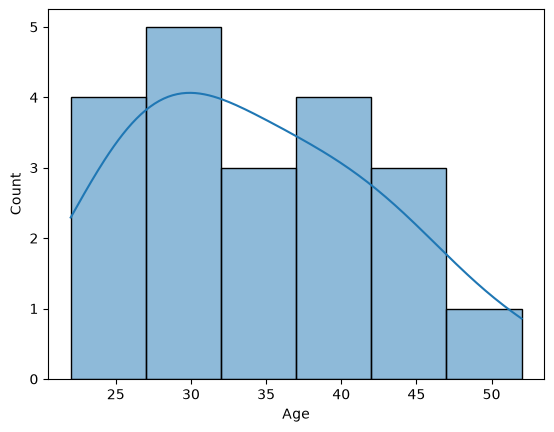

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=customers, x='Age',  kde=True)

<Axes: xlabel='Gender', ylabel='count'>

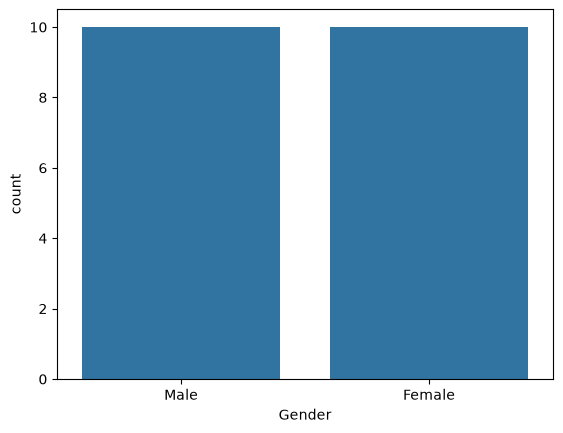

In [33]:
sns.countplot(data=customers,x='Gender')

In [24]:
print(customers['Gender'].value_counts())

Gender
Male      10
Female    10
Name: count, dtype: int64


## Question 2: Feature Engineering



### a: convert continous age column into categorical age group ("youth","adult")

In [35]:
ages = pd.read_csv("ages.csv")
ages.head()

,CustomerID,Name,Age,Gender,Occupation,AnnualIncome
0,C001,Ankit Shah,17,Male,Student,120000
1,C002,Neha Verma,21,Female,Student,180000
2,C003,Rahul Khanna,26,Male,Engineer,500000
3,C004,Priya Desai,34,Female,Teacher,420000
4,C005,Manoj Mehta,39,Male,Doctor,720000


In [36]:
ages['Age'].describe()

count    20.000000
mean     43.500000
std      17.584383
min      17.000000
25%      28.250000
50%      43.000000
75%      58.750000
max      70.000000
Name: Age, dtype: float64

In [48]:
bins = [0,18,25,60,80]

labels = ['Child', 'Youth','Adult','Fossil']

ages['Age_Category'] = pd.cut(ages['Age'], bins=bins, labels=labels)

ages.head()

# The pd.cut() function in pandas is used to convert continuous numerical data into discrete categories or "bins". It is ideal for grouping a range of numbers (like Age) into specific intervals (like Age Groups).

,CustomerID,Name,Age,Gender,Occupation,AnnualIncome,Age_Category
0,C001,Ankit Shah,17,Male,Student,120000,Child
1,C002,Neha Verma,21,Female,Student,180000,Youth
2,C003,Rahul Khanna,26,Male,Engineer,500000,Adult
3,C004,Priya Desai,34,Female,Teacher,420000,Adult
4,C005,Manoj Mehta,39,Male,Doctor,720000,Adult


<Axes: xlabel='Age', ylabel='Count'>

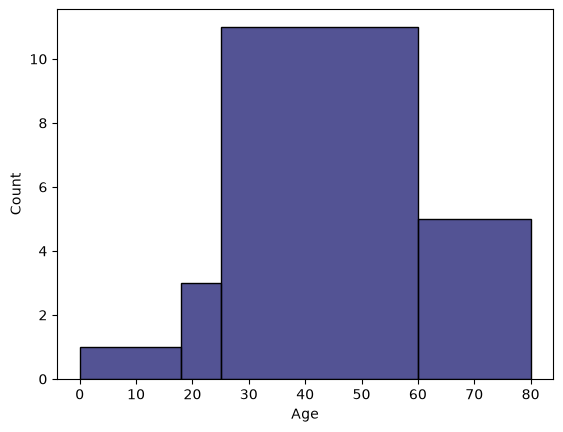

In [52]:
sns.histplot(data=ages, x='Age',bins=bins,color='midnightblue')

<Axes: xlabel='Age_Category', ylabel='count'>

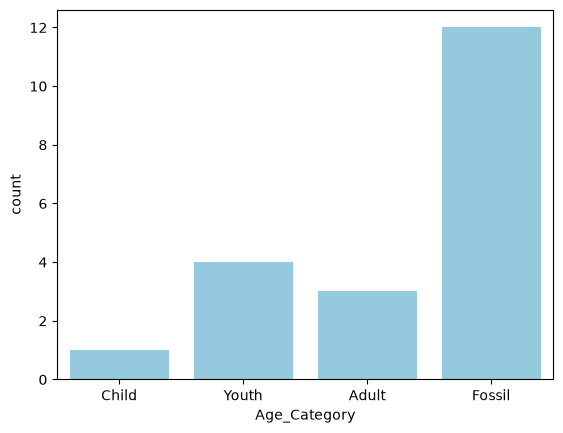

In [45]:
sns.countplot(data=ages,x='Age_Category',color='skyblue')

### b: retail store to understand the customer purchasing behavior over time

In [53]:
sales = pd.read_csv('sales.csv')

print(sales.head())


  CustomerID  CustomerName             Item  Quantity  UnitPrice        Date
0       C001    Ankit Shah   Wireless Mouse         2        750  2024-01-05
1       C002    Neha Verma  Laptop Backpack         1       1850  2024-01-08
2       C003  Rahul Khanna    USB-C Charger         3        650  2024-01-09
3       C004   Priya Desai       Smartphone         1      22000  2024-01-10
4       C005   Manoj Mehta         Keyboard         2       1200  2024-01-11


In [54]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CustomerID    20 non-null     str  
 1   CustomerName  20 non-null     str  
 2   Item          20 non-null     str  
 3   Quantity      20 non-null     int64
 4   UnitPrice     20 non-null     int64
 5   Date          20 non-null     str  
dtypes: int64(2), str(4)
memory usage: 1.1 KB


#### i) Extract day of week and month 

In [55]:
# date column in a string
sales['Date'] = pd.to_datetime(sales['Date'])

sales['Day'] = sales['Date'].dt.day_name()

In [56]:
sales['Month'] = sales['Date'].dt.month_name()

In [57]:
sales.head()

,CustomerID,CustomerName,Item,Quantity,UnitPrice,Date,Day,Month
0,C001,Ankit Shah,Wireless Mouse,2,750,2024-01-05,Friday,January
1,C002,Neha Verma,Laptop Backpack,1,1850,2024-01-08,Monday,January
2,C003,Rahul Khanna,USB-C Charger,3,650,2024-01-09,Tuesday,January
3,C004,Priya Desai,Smartphone,1,22000,2024-01-10,Wednesday,January
4,C005,Manoj Mehta,Keyboard,2,1200,2024-01-11,Thursday,January


#### ii) if total purchase is more than 10000 mark it 1 else 0

In [65]:
sales['TotalPurchase'] = sales['Quantity'] * sales['UnitPrice']



In [68]:
sales['High_Value'] = (sales['TotalPurchase'] > 10000).astype(int)

In [69]:
sales.head()

,CustomerID,CustomerName,Item,Quantity,UnitPrice,Date,Day,Month,TotalPurchase,High_Value
0,C001,Ankit Shah,Wireless Mouse,2,750,2024-01-05,Friday,January,1500,0
1,C002,Neha Verma,Laptop Backpack,1,1850,2024-01-08,Monday,January,1850,0
2,C003,Rahul Khanna,USB-C Charger,3,650,2024-01-09,Tuesday,January,1950,0
3,C004,Priya Desai,Smartphone,1,22000,2024-01-10,Wednesday,January,22000,1
4,C005,Manoj Mehta,Keyboard,2,1200,2024-01-11,Thursday,January,2400,0


#### iii) create category using mapping

In [ ]:
category_mapping = {
    'Wireless Mouse': 'Accessories',
    'Laptop Backpack': 'Accessories',
    'USB-C Charger': 'Accessories',
    'Keyboard': 'Accessories',
    'Webcam': 'Accessories',
    'Wireless Router': 'Accessories',
    'Pen Drive': 'Accessories',
    'External HDD': 'Accessories',
    'HDMI Cable': 'Accessories',
    'Power Bank': 'Accessories',
    'Laptop Stand': 'Accessories',
    'Stylus Pen': 'Accessories',
    'Mouse Pad': 'Accessories',

    'Smartphone': 'Electronics',
    'Headphones': 'Electronics',
    'Monitor': 'Electronics',
    'Smartwatch': 'Electronics',
    'Tablet': 'Electronics',
    'Speaker': 'Electronics',
    'Printer': 'Electronics'
}


sales['Category'] = sales['Item'].map(category_mapping)

print(sales.head())

  CustomerID  CustomerName             Item  Quantity  UnitPrice       Date  \
0       C001    Ankit Shah   Wireless Mouse         2        750 2024-01-05   
1       C002    Neha Verma  Laptop Backpack         1       1850 2024-01-08   
2       C003  Rahul Khanna    USB-C Charger         3        650 2024-01-09   
3       C004   Priya Desai       Smartphone         1      22000 2024-01-10   
4       C005   Manoj Mehta         Keyboard         2       1200 2024-01-11   

         Day    Month  TotalPurchase  High_Value     Category  
0     Friday  January           1500           0  Accessories  
1     Monday  January           1850           0  Accessories  
2    Tuesday  January           1950           0  Accessories  
3  Wednesday  January          22000           1  Electronics  
4   Thursday  January           2400           0  Accessories  


## 3) Missing Values

### a) retail chain's customer dataset

#### i) identify columns with missing data
#### ii) fill age - mean and annual Income - median
#### iii) missing gender values - fill with mode
#### iv) ensure the cleaned dataset


In [3]:
retail = pd.read_csv('missing_customers.csv')
retail.head()

,CustomerID,Name,Gender,Age,AnnualIncome,LoyaltyScore,Membership
0,101,Anjali,Female,25.0,50000.0,7.0,Silver
1,102,Ravi,Male,34.0,62000.0,8.0,Gold
2,103,Meena,Female,NaN,57000.0,6.0,Silver
3,104,Sohan,Male,29.0,NaN,9.0,Gold
4,105,Geeta,NaN,31.0,49000.0,7.0,Platinum


<Axes: xlabel='AnnualIncome', ylabel='LoyaltyScore'>

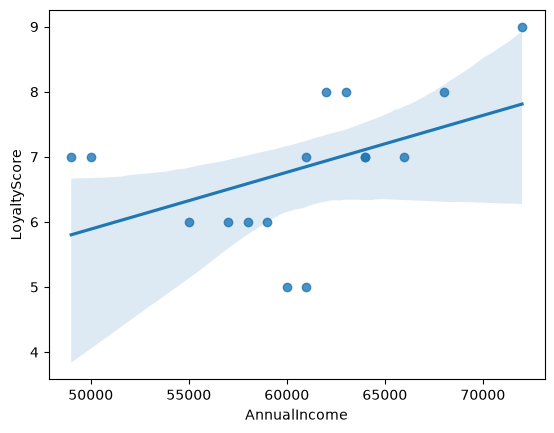

In [7]:
sns.regplot(data=retail, x='AnnualIncome',y='LoyaltyScore')

<Axes: xlabel='Age', ylabel='LoyaltyScore'>

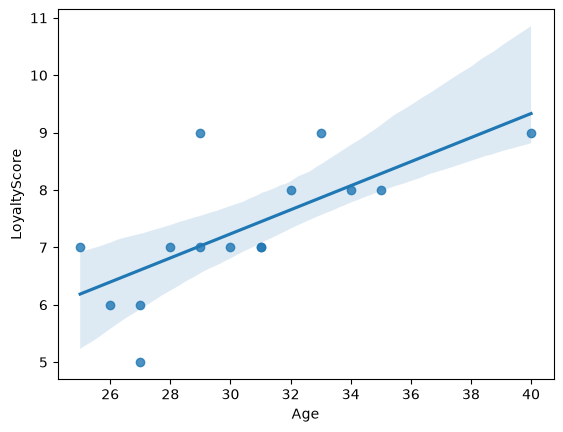

In [8]:
sns.regplot(data=retail, x='Age',y='LoyaltyScore')

<Axes: xlabel='Membership', ylabel='LoyaltyScore'>

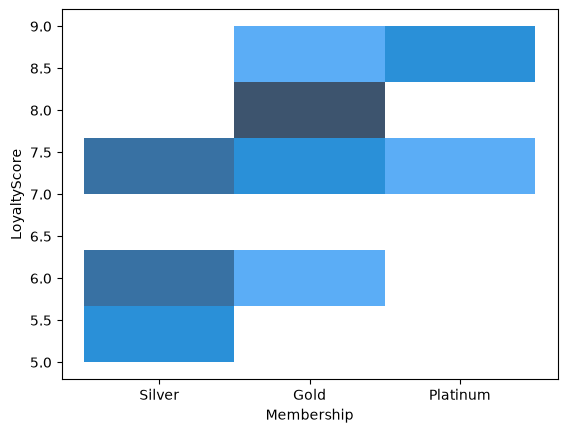

In [15]:
sns.histplot(data=retail,x='Membership',y='LoyaltyScore')

In [4]:
print("Missing values")
print(retail.isnull().sum())

Missing values
CustomerID      0
Name            0
Gender          2
Age             4
AnnualIncome    3
LoyaltyScore    1
Membership      0
dtype: int64


In [5]:
print(retail['LoyaltyScore'].value_counts())

LoyaltyScore
7.0    6
8.0    4
6.0    4
9.0    3
5.0    2
Name: count, dtype: int64


In [19]:
retail['Age'] = retail['Age'].fillna(retail['Age'].mean())

retail['AnnualIncome'] = retail['AnnualIncome'].fillna(retail['AnnualIncome'].median())

retail['Gender'] = retail['Gender'].fillna(retail['Gender'].mode()[0])

retail['LoyaltyScore'] = retail['LoyaltyScore'].fillna(retail['LoyaltyScore'].median())

print(retail.isnull().sum())



CustomerID      0
Name            0
Gender          0
Age             0
AnnualIncome    0
LoyaltyScore    0
Membership      0
dtype: int64


### b) uni exam results

#### i) Detect rows containing missing values
#### ii) Drop rows with any missing value
#### iii) Display clean dataset


In [20]:
exam = pd.read_csv("exam_results.csv")
exam.head()

,StudentID,Name,Subject,Score,Grade,Remarks
0,201,Arjun,Maths,88.0,A,Excellent
1,202,Neha,English,NaN,B,Good
2,203,Rahul,Science,75.0,B,Fair
3,204,Isha,NaN,68.0,C,Needs Improvement
4,205,Kunal,Maths,92.0,A,Excellent


In [22]:
print(exam.isnull().sum())
print(exam[exam.isnull().any(axis=1)])

StudentID    0
Name         0
Subject      2
Score        4
Grade        1
Remarks      0
dtype: int64
    StudentID    Name  Subject  Score Grade            Remarks
1         202    Neha  English    NaN     B               Good
3         204    Isha      NaN   68.0     C  Needs Improvement
6         207  Sachin  Science    NaN     B               Fair
7         208   Aarti    Maths   78.0   NaN            Average
14        215   Tarun  English    NaN     B               Fair
16        217  Vishal      NaN   85.0     A          Excellent
19        220   Rekha  Science    NaN     C               Fair


In [23]:
exam_clean = exam.dropna()
print(exam_clean)

    StudentID       Name  Subject  Score Grade            Remarks
0         201      Arjun    Maths   88.0     A          Excellent
2         203      Rahul  Science   75.0     B               Fair
4         205      Kunal    Maths   92.0     A          Excellent
5         206      Priya  English   85.0     B               Good
8         209      Harsh  English   81.0     B               Good
9         210     Nikita  Science   90.0     A          Excellent
10        211      Manoj    Maths   84.0     B               Good
11        212      Komal  English   76.0     C               Fair
12        213  Siddharth  Science   69.0     C  Needs Improvement
13        214      Megha    Maths   88.0     A          Excellent
15        216      Naina  Science   80.0     B               Good
17        218     Trisha  English   89.0     A          Excellent
18        219     Nitesh    Maths   90.0     A          Excellent


In [25]:
print(exam_clean.isnull().sum())

StudentID    0
Name         0
Subject      0
Score        0
Grade        0
Remarks      0
dtype: int64


## 4) EDA - Univariate and Bivariate analysis

### a) retail company has a customer dataset containing demographic and spending info, perform EDA

#### Univariate
#### i) ages histogram
#### ii) gender count plot
#### ii) spending score box plot


In [26]:
customer_data = pd.read_csv("customer_data.csv")
customer_data.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Membership
0,1,Female,22,30000,45,Silver
1,2,Male,35,50000,60,Gold
2,3,Female,29,35000,65,Silver
3,4,Male,40,80000,30,Platinum
4,5,Female,23,27000,75,Silver


In [27]:
customer_data.describe()

,CustomerID,Age,AnnualIncome,SpendingScore
count,20.00000,20.000000,20.000000,20.000000
mean,10.50000,32.900000,54300.000000,47.850000
std,5.91608,6.766014,22290.191376,18.207214
min,1.00000,22.000000,27000.000000,20.000000
25%,5.75000,27.750000,35750.000000,32.250000
50%,10.50000,32.500000,45500.000000,48.500000
75%,15.25000,38.250000,70500.000000,63.500000
max,20.00000,45.000000,95000.000000,75.000000


<Axes: xlabel='Age', ylabel='Count'>

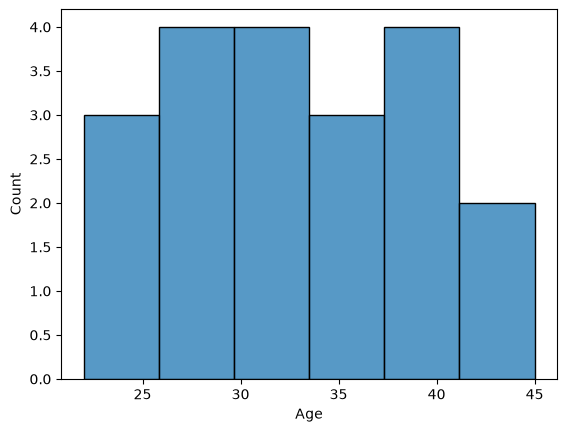

In [28]:
sns.histplot(data=customer_data,x='Age')

<Axes: xlabel='Gender', ylabel='count'>

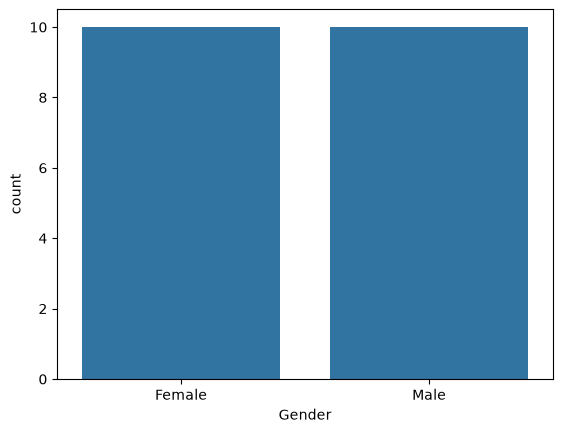

In [29]:
sns.countplot(data=customer_data,x='Gender')

In [30]:
print(customer_data['Gender'].value_counts())

Gender
Female    10
Male      10
Name: count, dtype: int64


<Axes: ylabel='SpendingScore'>

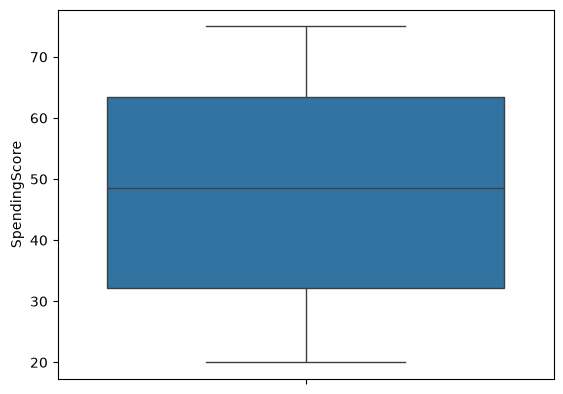

In [31]:
sns.boxplot(customer_data['SpendingScore'])

#### Bivariate Analysis
#### iv) relationship between age and spending score - scatter plot
#### v) Spending behavior across genders - bar plot
#### vi) Compare annual income with spending score using scatter plot/ reg plot

<Axes: xlabel='SpendingScore', ylabel='Age'>

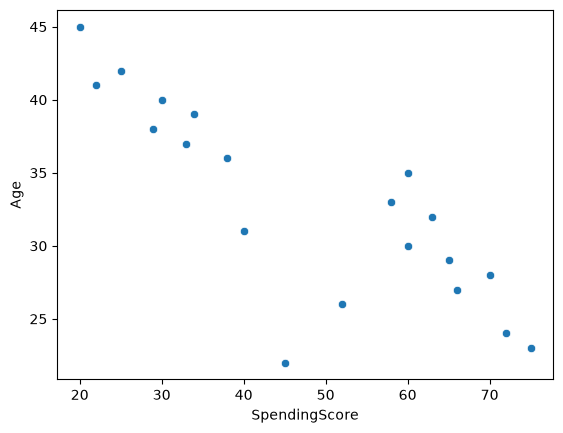

In [32]:
sns.scatterplot(data=customer_data,x='SpendingScore',y='Age')

Text(0, 0.5, 'Average Spending Score')

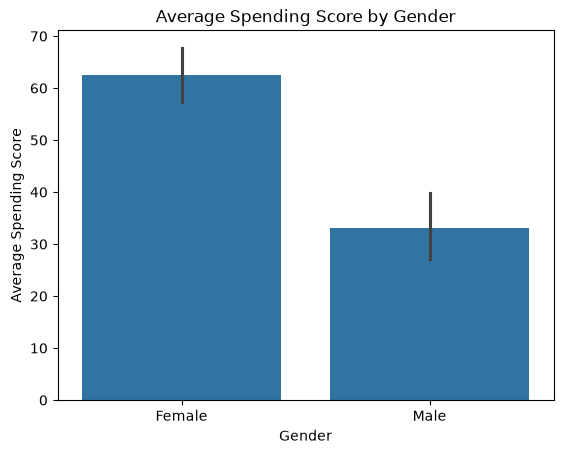

In [34]:
sns.barplot(data=customer_data,x='Gender',y='SpendingScore')
plt.title("Average Spending Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Spending Score")


<Axes: xlabel='AnnualIncome', ylabel='SpendingScore'>

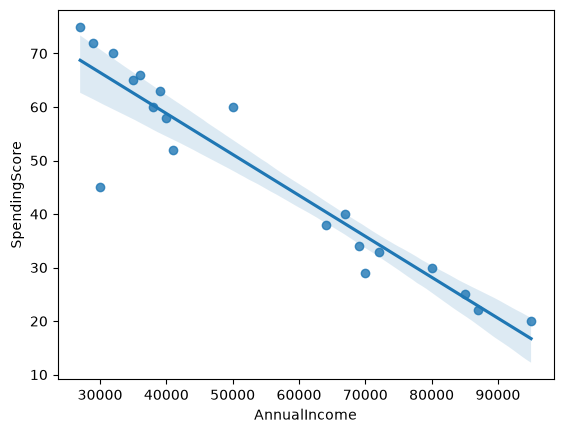

In [35]:
sns.regplot(data=customer_data,x='AnnualIncome',y='SpendingScore')

### b) Retail sales dataset containing info about products and sales

#### Univariate Analysis
#### i) unit prices - histogram
#### ii) total sales - boxplot

In [36]:
product_sales = pd.read_csv("product_sales.csv")
product_sales.head()

,ProductID,Category,Region,UnitPrice,QuantitySold,TotalSales,Discount
0,101,Electronics,North,1200,15,18000,0.10
1,102,Fashion,South,1500,8,12000,0.15
2,103,Electronics,West,1100,20,22000,0.05
3,104,Home,East,900,18,16200,0.10
4,105,Fashion,North,1300,12,15600,0.20


In [37]:
product_sales.describe()

,ProductID,UnitPrice,QuantitySold,TotalSales,Discount
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,110.50000,1239.000000,13.000000,15470.000000,0.085000
std,5.91608,250.681177,3.769685,3426.280782,0.054047
min,101.00000,850.000000,7.000000,10150.000000,0.000000
25%,105.75000,965.000000,10.000000,13275.000000,0.050000
50%,110.50000,1325.000000,13.000000,14860.000000,0.100000
75%,115.25000,1412.500000,15.250000,17175.000000,0.100000
max,120.00000,1600.000000,20.000000,23750.000000,0.200000


In [38]:
product_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     20 non-null     int64  
 1   Category      20 non-null     str    
 2   Region        20 non-null     str    
 3   UnitPrice     20 non-null     int64  
 4   QuantitySold  20 non-null     int64  
 5   TotalSales    20 non-null     int64  
 6   Discount      20 non-null     float64
dtypes: float64(1), int64(4), str(2)
memory usage: 1.2 KB


<Axes: xlabel='UnitPrice', ylabel='Count'>

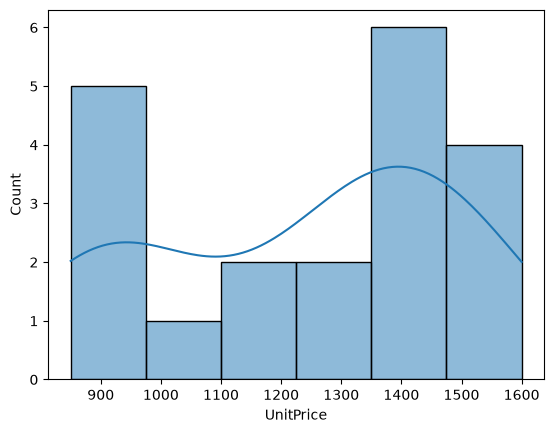

In [39]:
sns.histplot(data=product_sales,x='UnitPrice',kde=True)

Text(0.5, 1.0, 'Total Sales')

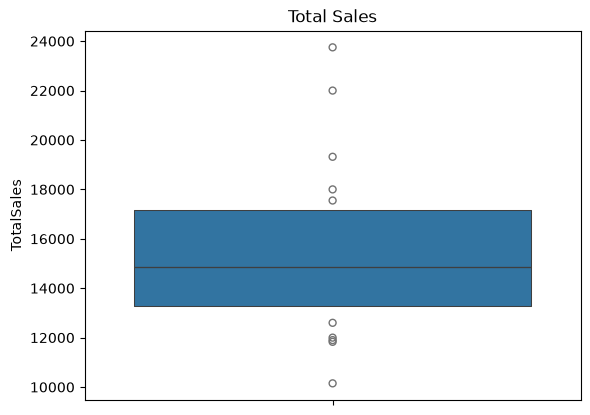

In [43]:
sns.boxenplot(product_sales['TotalSales'])
plt.title("Total Sales")

#### Bivariate Analysis

#### iii) top selling products using total sales grouped by category
#### iv) compare regional sales performance using par plot
#### v) count plot for number of products solde across regions and categories

Text(0.5, 1.0, 'Total Sales by Product Category')

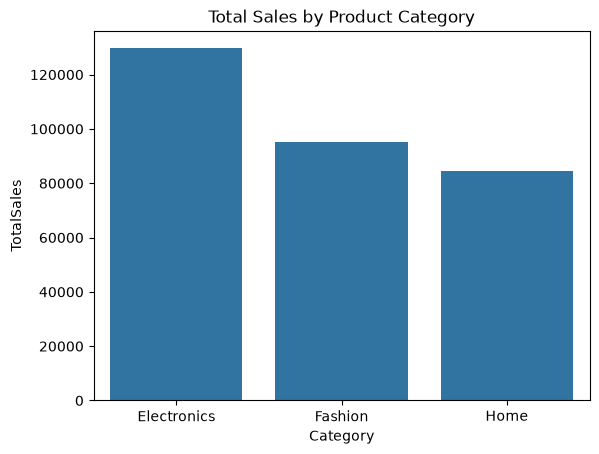

In [46]:
category_sales = product_sales.groupby('Category')['TotalSales'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=category_sales,x ='Category',y='TotalSales')
plt.title("Total Sales by Product Category")


In [47]:
regional_sales = product_sales.groupby('Region')['TotalSales'].sum().reset_index()

Text(0.5, 1.0, 'Regional Sales Performance')

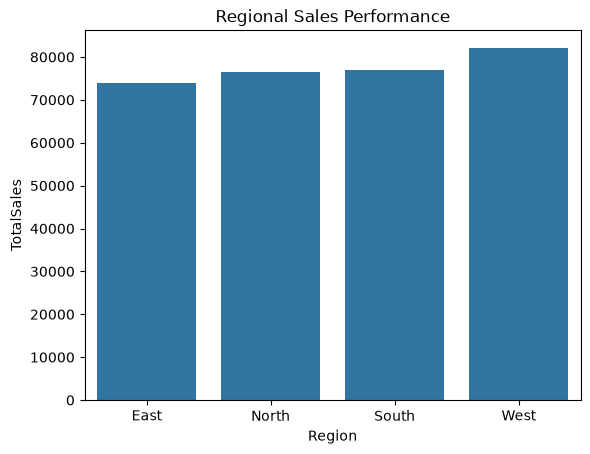

In [49]:
sns.barplot(data=regional_sales,x='Region',y='TotalSales')
plt.title("Regional Sales Performance")

Text(0.5, 1.0, 'Number of Products Across Regions and Categories')

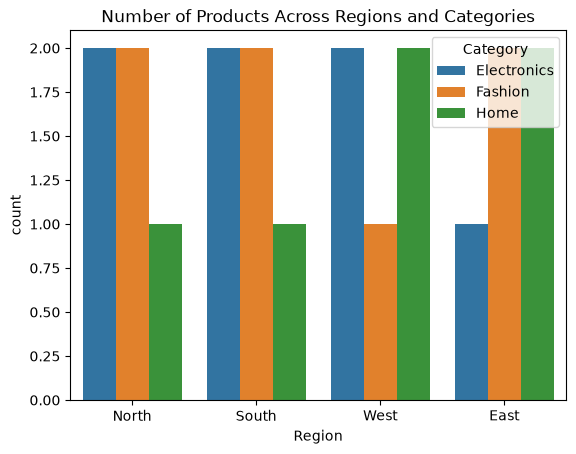

In [53]:
sns.countplot(data=product_sales,x='Region',hue='Category')
plt.title("Number of Products Across Regions and Categories")

## 5) EDA - Multivariate Analysis

In [54]:
student_scores = pd.read_csv("student_scores.csv")
student_scores.head()

,StudentID,Gender,ParentalEducation,Lunch,MathScore,ReadingScore,WritingScore
0,1,Female,Bachelor,Standard,78,85,82
1,2,Male,HighSchool,Free,65,70,68
2,3,Female,Master,Standard,90,95,92
3,4,Male,Associate,Standard,72,75,70
4,5,Female,SomeCollege,Free,60,65,63


In [55]:
student_scores.describe()

,StudentID,MathScore,ReadingScore,WritingScore
count,20.00000,20.000000,20.000000,20.000000
mean,10.50000,73.500000,75.900000,75.550000
std,5.91608,11.394828,10.442323,11.771844
min,1.00000,58.000000,61.000000,60.000000
25%,5.75000,63.750000,66.750000,65.750000
50%,10.50000,72.500000,75.500000,73.000000
75%,15.25000,82.750000,85.250000,86.000000
max,20.00000,92.000000,95.000000,93.000000


In [56]:
student_scores.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   StudentID          20 non-null     int64
 1   Gender             20 non-null     str  
 2   ParentalEducation  20 non-null     str  
 3   Lunch              20 non-null     str  
 4   MathScore          20 non-null     int64
 5   ReadingScore       20 non-null     int64
 6   WritingScore       20 non-null     int64
dtypes: int64(4), str(3)
memory usage: 1.2 KB


#### i) average performance by gender - grouped bar chart


In [58]:
gender_scores = student_scores.groupby('Gender')[['MathScore','ReadingScore','WritingScore']].mean()
print(gender_scores)

        MathScore  ReadingScore  WritingScore
Gender                                       
Female       72.4          75.8          75.2
Male         74.6          76.0          75.9


(0.0, 100.0)

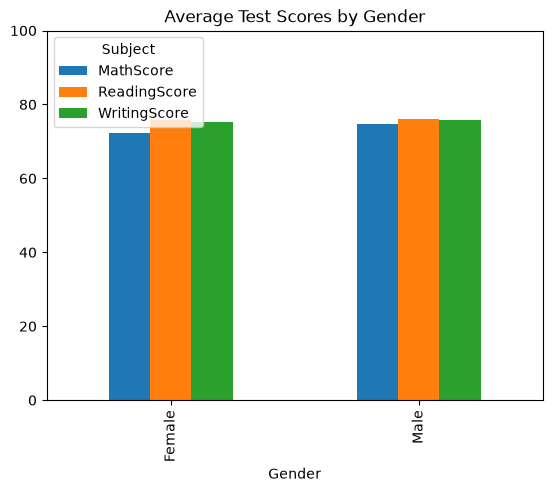

In [64]:
gender_scores.plot(kind='bar')
plt.title('Average Test Scores by Gender')
plt.legend(title='Subject')
plt.ylim(0, 100)        

#### ii) effect of parental education on scores - boxplot for math,reading and writing

Text(0.5, 1.0, 'Math Scores by Parental Education')

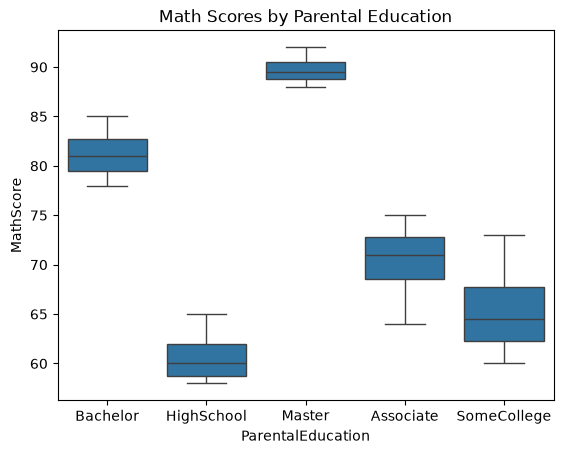

In [67]:
sns.boxplot(data=student_scores, y='MathScore',x='ParentalEducation')
plt.title("Math Scores by Parental Education")


Text(0.5, 1.0, 'Reading Scores by Parental Education')

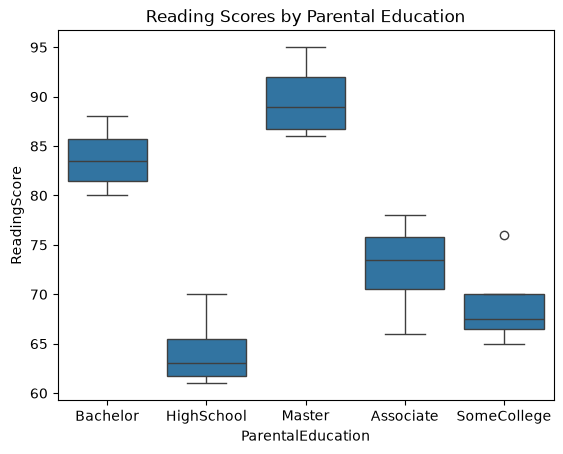

In [68]:
sns.boxplot(data=student_scores, y='ReadingScore',x='ParentalEducation')
plt.title("Reading Scores by Parental Education")


Text(0.5, 1.0, 'Writing Scores by Parental Education')

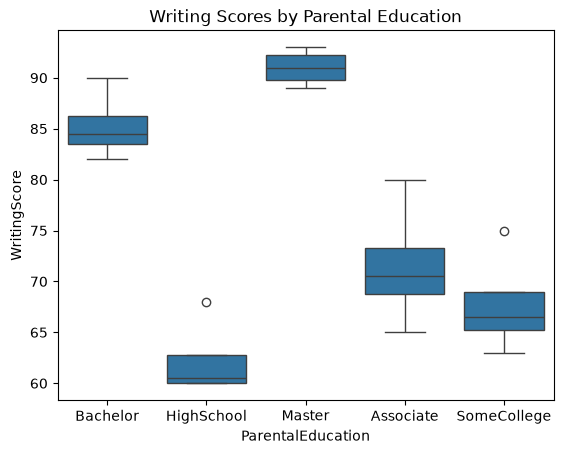

In [69]:
sns.boxplot(data=student_scores, y='WritingScore',x='ParentalEducation')
plt.title("Writing Scores by Parental Education")


#### iii) impact of lunch type on academic performance - violin plot/box plot

Text(0.5, 1.0, 'Math Score Distribution by Lunch Type')

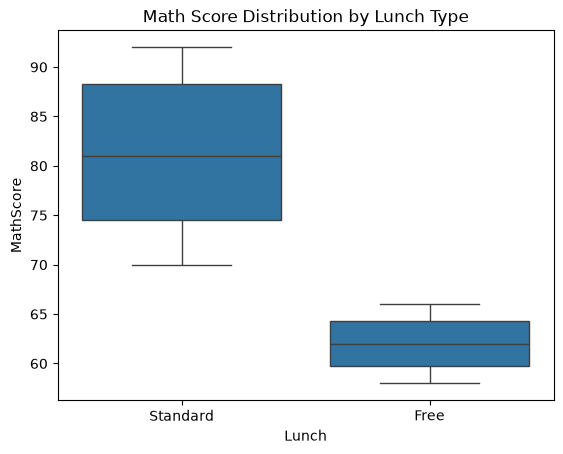

In [72]:
sns.boxplot(data=student_scores,x='Lunch',y='MathScore')
plt.title("Math Score Distribution by Lunch Type")

Text(0.5, 1.0, 'Reading Score Distribution by Lunch Type')

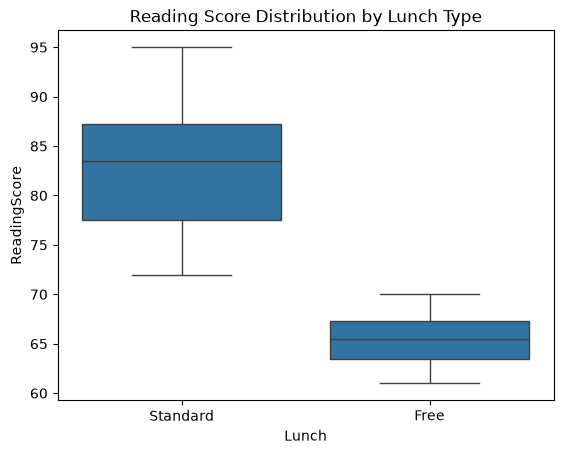

In [73]:
sns.boxplot(data=student_scores,x='Lunch',y='ReadingScore')
plt.title("Reading Score Distribution by Lunch Type")

Text(0.5, 1.0, 'Writing Score Distribution by Lunch Type')

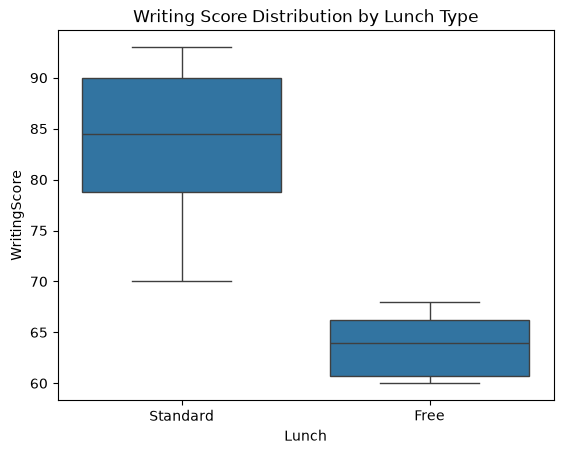

In [74]:
sns.boxplot(data=student_scores,x='Lunch',y='WritingScore')
plt.title("Writing Score Distribution by Lunch Type")

#### iv) correlation between math,reading,writing scored - heatmap

In [75]:
scores = student_scores[['MathScore','ReadingScore','WritingScore']]
correlation = scores.corr()

Text(0.5, 1.0, 'Correlation Between Academic Scores')

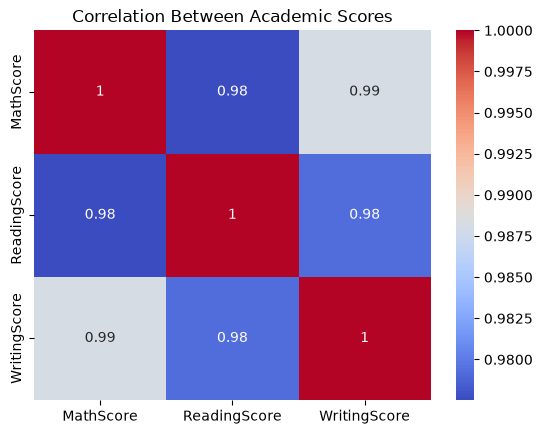

In [77]:
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation Between Academic Scores")

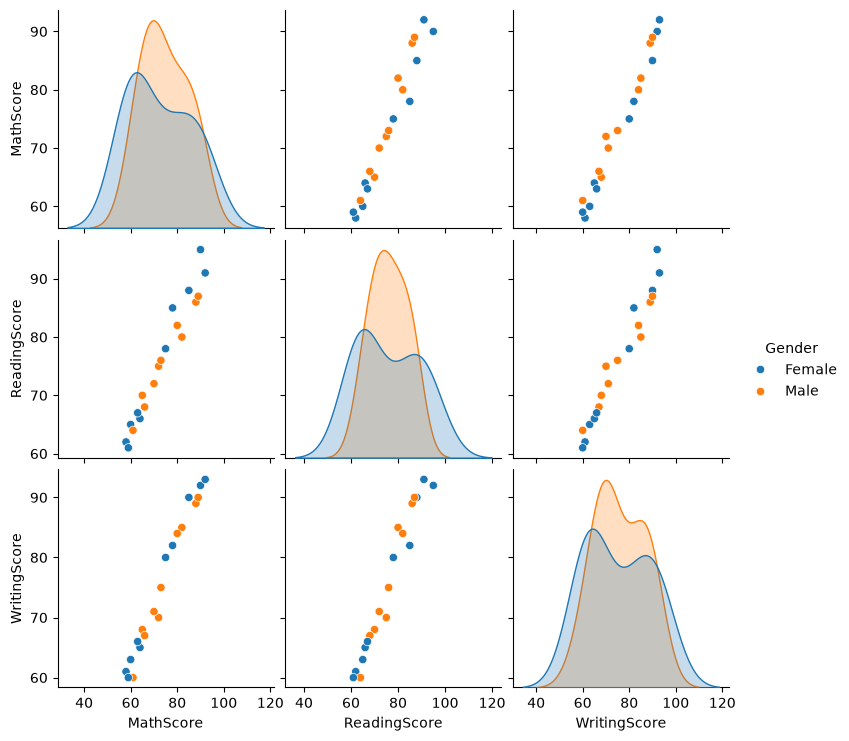

In [ ]:
sns.pairplot(student_scores,vars=['MathScore','ReadingScore','WritingScore'],hue='Gender')
# In Seaborn's pairplot(), vars means variables (columns) you want to include in the pair plot.

---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | Ishita Khandelwal|
| **PRN** | 125M1H044|
| **Date** | 31/08/2026|

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-01-green?style=flat-square)

</div>